# Leakage-Safe Multi-Dataset Speech Emotion Recognition

This is a corrected, reproducible replacement for the executed Kaggle notebook. It uses RAVDESS, CREMA-D and SAVEE for the primary speaker-independent benchmark. TESS is retained as an external-corpus test because it contains only two speakers and cannot support a credible train/validation/test speaker split.

The notebook maps RAVDESS calm to neutral, producing seven shared emotion classes: anger, disgust, fear, happiness, neutral, sadness and surprise.

## Experimental contract

- Complete speakers—not augmented rows—are assigned to train, validation and test partitions.
- Augmentation is applied only after the speaker split and only to training recordings.
- The scaler and balancing weights are fitted using training data only.
- Checkpoints, ensemble weights and deployment selection use validation macro F1 only.
- The held-out primary test and external TESS set are evaluated only after model selection.
- Accuracy and macro F1 are both reported; macro F1 is the primary metric.

In [1]:
# Kaggle's Python image already includes the required packages.
# If you run elsewhere and an import is missing, uncomment this line:
# %pip install -q librosa soundfile scipy scikit-learn seaborn joblib tqdm tensorflow

In [2]:
# Imports and configuration
import hashlib
import json
import os
import platform
import random
import re
from itertools import product
from pathlib import Path

import joblib
import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import soundfile as sf
import tensorflow as tf

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    roc_auc_score,
)
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from tqdm.auto import tqdm

sns.set_theme(style='whitegrid')
SEED = 42
SAMPLE_RATE = 16_000
DURATION_SECONDS = 4.0
N_SAMPLES = int(SAMPLE_RATE * DURATION_SECONDS)
N_MELS = 64
N_MFCC = 40
N_FFT = 512
HOP_LENGTH = 256

EMOTIONS = [
    'anger', 'disgust', 'fear', 'happiness',
    'neutral', 'sadness', 'surprise',
]
EMOTION_TO_ID = {emotion: index for index, emotion in enumerate(EMOTIONS)}
ID_TO_EMOTION = {index: emotion for emotion, index in EMOTION_TO_ID.items()}

DATASET_ROOTS = {
    'RAVDESS': Path('/kaggle/input/ravdess-emotional-speech-audio/audio_speech_actors_01-24'),
    'CREMA-D': Path('/kaggle/input/cremad/AudioWAV'),
    'TESS': Path('/kaggle/input/toronto-emotional-speech-set-tess/tess toronto emotional speech set data/TESS Toronto emotional speech set data'),
    'SAVEE': Path('/kaggle/input/surrey-audiovisual-expressed-emotion-savee/ALL'),
}
PRIMARY_DATASETS = ['RAVDESS', 'CREMA-D', 'SAVEE']
EXTERNAL_DATASET = 'TESS'
ARTIFACT_ROOT = Path('/kaggle/working/ser_corrected_artifacts')
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)

VERIFY_CONTENT_HASHES = False
REBUILD_FEATURE_CACHE = False
TRAIN_AUGMENTATIONS_PER_FILE = 2
RUN_RBF_SVM = True
MLP_EPOCHS = 80
MLP_BATCH_SIZE = 128
MLP_PATIENCE = 12

def seed_everything(seed=SEED):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)
    try:
        tf.config.experimental.enable_op_determinism()
    except Exception:
        pass

seed_everything()
print('Python:', platform.python_version())
print('TensorFlow:', tf.__version__)
print('librosa:', librosa.__version__)
print('scikit-learn:', sklearn.__version__)
print('GPUs:', tf.config.list_physical_devices('GPU'))

Python: 3.13.15
TensorFlow: 2.20.0
librosa: 0.11.0
scikit-learn: 1.6.1
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
import sys
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_ROOT = Path('/content/drive/MyDrive')
else:
    DRIVE_ROOT = Path.cwd()

DATASET_ROOTS = {
    'RAVDESS': DRIVE_ROOT / 'RAVDESS DATASET',
    'CREMA-D': DRIVE_ROOT / 'CREMA-D',
    'TESS': DRIVE_ROOT / 'TESS',
    'SAVEE': DRIVE_ROOT / 'SAVEE DATASET',
}

# --- Fix: save outputs to Google Drive instead of /kaggle/working ---
ARTIFACT_ROOT = DRIVE_ROOT / 'ser_corrected_artifacts'
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)

Mounted at /content/drive


## Build an auditable manifest

Speaker identifiers are parsed from filenames before any splitting. RAVDESS calm is merged into neutral so that the benchmark has one consistent seven-class label space.

In [4]:
import re
import hashlib
import pandas as pd
from tqdm import tqdm

# Dataset-specific filename parsers
AUDIO_SUFFIXES = {'.wav', '.flac', '.mp3', '.ogg', '.m4a'}

def audio_files(root):
    return sorted(
        path for path in root.rglob('*')
        if path.is_file() and path.suffix.lower() in AUDIO_SUFFIXES
    )

def parse_ravdess(path):
    parts = path.stem.split('-')
    if len(parts) < 7:
        return None
    emotion = {
        1: 'neutral', 2: 'neutral', 3: 'happiness', 4: 'sadness',
        5: 'anger', 6: 'fear', 7: 'disgust', 8: 'surprise',
    }.get(int(parts[2]))
    return emotion, f'RAVDESS_{parts[6]}'

def parse_crema(path):
    parts = path.stem.split('_')
    if len(parts) < 3:
        return None
    emotion = {
        'ANG': 'anger', 'DIS': 'disgust', 'FEA': 'fear',
        'HAP': 'happiness', 'NEU': 'neutral', 'SAD': 'sadness',
    }.get(parts[2].upper())
    return emotion, f'CREMA-D_{parts[0]}'

def parse_tess(path):
    parts = path.stem.split('_')
    if len(parts) < 2:
        return None
    raw_emotion = parts[-1].lower()
    emotion = {
        'angry': 'anger', 'disgust': 'disgust', 'fear': 'fear',
        'happy': 'happiness', 'neutral': 'neutral', 'sad': 'sadness',
        'ps': 'surprise', 'surprise': 'surprise',
    }.get(raw_emotion)
    return emotion, f'TESS_{parts[0].upper()}'

def parse_savee(path):
    parts = path.stem.split('_')
    if len(parts) < 2:
        return None
    match = re.match(r'([a-zA-Z]+)', parts[1])
    if match is None:
        return None
    emotion = {
        'a': 'anger', 'd': 'disgust', 'f': 'fear',
        'h': 'happiness', 'n': 'neutral', 'sa': 'sadness',
        'su': 'surprise',
    }.get(match.group(1).lower())
    return emotion, f'SAVEE_{parts[0].upper()}'

PARSERS = {
    'RAVDESS': parse_ravdess,
    'CREMA-D': parse_crema,
    'TESS': parse_tess,
    'SAVEE': parse_savee,
}

# --- Fixed: check against Google Drive paths, not Kaggle ---
for dataset, root in DATASET_ROOTS.items():
    if not root.exists():
        raise FileNotFoundError(
            f'{dataset} root does not exist: {root}. '
            f'Check that this folder exists in your Google Drive under My Drive.'
        )

records = []
for dataset, root in DATASET_ROOTS.items():
    parser = PARSERS[dataset]
    for path in audio_files(root):
        parsed = parser(path)
        if parsed is None or parsed[0] not in EMOTION_TO_ID:
            continue
        emotion, speaker = parsed
        relative_path = str(path.relative_to(root))
        sample_id = hashlib.sha1(
            f'{dataset}|{relative_path}'.encode('utf-8')
        ).hexdigest()[:16]
        records.append({
            'sample_id': sample_id,
            'dataset': dataset,
            'speaker': speaker,
            'emotion': emotion,
            'filepath': str(path),
        })

manifest = pd.DataFrame(records).drop_duplicates('filepath').reset_index(drop=True)
if manifest.empty:
    raise RuntimeError('No audio files were discovered.')

if VERIFY_CONTENT_HASHES:
    def sha256_file(filepath, block_size=1024 * 1024):
        digest = hashlib.sha256()
        with open(filepath, 'rb') as handle:
            while True:
                block = handle.read(block_size)
                if not block:
                    break
                digest.update(block)
        return digest.hexdigest()

    manifest['sha256'] = [
        sha256_file(path)
        for path in tqdm(manifest.filepath, desc='Duplicate hashes')
    ]
    before = len(manifest)
    manifest = manifest.drop_duplicates('sha256').reset_index(drop=True)
    print('Exact duplicates removed:', before - len(manifest))

print('Files:', len(manifest))
print('Speakers:', manifest.speaker.nunique())
display(pd.crosstab(manifest.dataset, manifest.emotion))
display(manifest.groupby('dataset').speaker.nunique().rename('speakers'))

Files: 14962
Speakers: 122


emotion,anger,disgust,fear,happiness,neutral,sadness,surprise
dataset,,,,,,,
CREMA-D,1271,1271,1271,1271,1087,1271,0
RAVDESS,192,192,192,192,288,192,192
SAVEE,60,60,60,60,120,60,60
TESS,800,800,800,800,800,800,800


,speakers
dataset,
CREMA-D,91
RAVDESS,24
SAVEE,4
TESS,3


## Speaker-disjoint primary split

Each primary corpus contributes complete speakers to training, validation and testing. TESS is never used for training, preprocessing, checkpoint selection or ensemble selection.

In [5]:
# Deterministic 70/15/15 allocation of speakers within each primary corpus
primary_manifest = manifest[
    manifest.dataset.isin(PRIMARY_DATASETS)
].copy().reset_index(drop=True)
external_manifest = manifest[
    manifest.dataset.eq(EXTERNAL_DATASET)
].copy().reset_index(drop=True)

def corpus_seed(dataset):
    return SEED + sum(ord(character) for character in dataset)

speaker_to_split = {}
for dataset in PRIMARY_DATASETS:
    speakers = np.array(sorted(
        primary_manifest.loc[
            primary_manifest.dataset.eq(dataset), 'speaker'
        ].unique()
    ))
    if len(speakers) < 3:
        raise ValueError(
            f'{dataset} needs at least three speakers for a three-way split.'
        )
    rng = np.random.default_rng(corpus_seed(dataset))
    speakers = rng.permutation(speakers)
    n_test = max(1, int(round(len(speakers) * 0.15)))
    n_validation = max(1, int(round(len(speakers) * 0.15)))
    if n_test + n_validation >= len(speakers):
        n_test = 1
        n_validation = 1
    test_speakers_local = speakers[:n_test]
    validation_speakers_local = speakers[
        n_test:n_test + n_validation
    ]
    train_speakers_local = speakers[n_test + n_validation:]
    speaker_to_split.update({speaker: 'test' for speaker in test_speakers_local})
    speaker_to_split.update({
        speaker: 'validation' for speaker in validation_speakers_local
    })
    speaker_to_split.update({speaker: 'train' for speaker in train_speakers_local})

primary_manifest['split'] = primary_manifest.speaker.map(speaker_to_split)
if primary_manifest.split.isna().any():
    raise RuntimeError('Some primary speakers were not assigned to a split.')

train_manifest = primary_manifest[primary_manifest.split.eq('train')].copy()
validation_manifest = primary_manifest[
    primary_manifest.split.eq('validation')
].copy()
test_manifest = primary_manifest[primary_manifest.split.eq('test')].copy()

train_speakers = set(train_manifest.speaker)
validation_speakers = set(validation_manifest.speaker)
test_speakers = set(test_manifest.speaker)
assert train_speakers.isdisjoint(validation_speakers)
assert train_speakers.isdisjoint(test_speakers)
assert validation_speakers.isdisjoint(test_speakers)
assert set(external_manifest.speaker).isdisjoint(
    train_speakers | validation_speakers | test_speakers
)

for split_name, frame in [
    ('train', train_manifest),
    ('validation', validation_manifest),
    ('test', test_manifest),
    ('external_tess', external_manifest),
]:
    print(
        f'{split_name:14s}: {len(frame):5d} files, '
        f'{frame.speaker.nunique():3d} speakers'
    )
    display(pd.crosstab(frame.dataset, frame.emotion))

primary_manifest.to_csv(
    ARTIFACT_ROOT / 'primary_manifest_with_split.csv', index=False
)
external_manifest.to_csv(
    ARTIFACT_ROOT / 'external_tess_manifest.csv', index=False
)

train         :  6352 files,  81 speakers


emotion,anger,disgust,fear,happiness,neutral,sadness,surprise
dataset,,,,,,,
CREMA-D,880,880,880,880,752,880,0
RAVDESS,128,128,128,128,192,128,128
SAVEE,30,30,30,30,60,30,30


validation    :  1502 files,  19 speakers


emotion,anger,disgust,fear,happiness,neutral,sadness,surprise
dataset,,,,,,,
CREMA-D,195,195,195,195,167,195,0
RAVDESS,32,32,32,32,48,32,32
SAVEE,15,15,15,15,30,15,15


test          :  1508 files,  19 speakers


emotion,anger,disgust,fear,happiness,neutral,sadness,surprise
dataset,,,,,,,
CREMA-D,196,196,196,196,168,196,0
RAVDESS,32,32,32,32,48,32,32
SAVEE,15,15,15,15,30,15,15


external_tess :  5600 files,   3 speakers


emotion,anger,disgust,fear,happiness,neutral,sadness,surprise
dataset,,,,,,,
TESS,800,800,800,800,800,800,800


## Train-only augmentation and acoustic features

Every validation, primary-test and external-TESS recording produces exactly one feature vector. Each training recording produces the original plus two deterministic augmentations. Because the split already exists, variants of one recording cannot cross a partition boundary.

In [6]:
# Audio preprocessing, augmentation and feature extraction
def load_trimmed_audio(filepath):
    audio, _ = librosa.load(filepath, sr=SAMPLE_RATE, mono=True)
    audio, _ = librosa.effects.trim(audio, top_db=30)
    if len(audio) == 0:
        audio = np.zeros(1, dtype=np.float32)
    return np.asarray(audio, dtype=np.float32)

def centre_crop_or_pad(audio):
    audio = np.asarray(audio, dtype=np.float32)
    if len(audio) > N_SAMPLES:
        start = (len(audio) - N_SAMPLES) // 2
        audio = audio[start:start + N_SAMPLES]
    elif len(audio) < N_SAMPLES:
        missing = N_SAMPLES - len(audio)
        left = missing // 2
        right = missing - left
        audio = np.pad(audio, (left, right))
    peak = np.max(np.abs(audio))
    if peak > 1.0:
        audio = audio / peak
    return audio.astype(np.float32)

def deterministic_rng(sample_id):
    value = int(hashlib.sha1(sample_id.encode('utf-8')).hexdigest()[:8], 16)
    return np.random.default_rng(SEED ^ value)

def training_augmentations(audio, sample_id):
    rng = deterministic_rng(sample_id)

    signal_rms = np.sqrt(np.mean(audio ** 2) + 1e-10)
    snr_db = rng.uniform(15.0, 30.0)
    noise_rms = signal_rms / (10.0 ** (snr_db / 20.0))
    noisy = audio + rng.normal(0.0, noise_rms, len(audio)).astype(np.float32)
    noisy *= rng.uniform(0.85, 1.15)

    speed_rate = rng.uniform(0.90, 1.10)
    transformed = librosa.effects.time_stretch(audio, rate=speed_rate)
    transformed = librosa.effects.pitch_shift(
        transformed, sr=SAMPLE_RATE, n_steps=rng.uniform(-1.5, 1.5)
    )
    max_shift = int(0.10 * SAMPLE_RATE)
    shift = int(rng.integers(-max_shift, max_shift + 1))
    if shift > 0:
        transformed = np.concatenate([
            np.zeros(shift, dtype=np.float32), transformed
        ])[:len(transformed)]
    elif shift < 0:
        transformed = np.concatenate([
            transformed[-shift:], np.zeros(-shift, dtype=np.float32)
        ])

    return [
        np.clip(noisy, -1.0, 1.0),
        np.clip(transformed, -1.0, 1.0),
    ]

def summarize(matrix):
    matrix = np.asarray(matrix)
    return np.concatenate([
        np.mean(matrix, axis=1),
        np.std(matrix, axis=1),
    ])

def extract_acoustic_features(audio):
    audio = centre_crop_or_pad(audio)
    stft = np.abs(librosa.stft(
        audio, n_fft=N_FFT, hop_length=HOP_LENGTH
    ))
    mel = librosa.feature.melspectrogram(
        y=audio, sr=SAMPLE_RATE, n_fft=N_FFT,
        hop_length=HOP_LENGTH, n_mels=N_MELS, power=2.0,
    )
    log_mel = librosa.power_to_db(mel + 1e-10, ref=np.max)
    mfcc = librosa.feature.mfcc(
        S=log_mel, sr=SAMPLE_RATE, n_mfcc=N_MFCC
    )
    delta_mfcc = librosa.feature.delta(mfcc)
    chroma = librosa.feature.chroma_stft(
        S=stft, sr=SAMPLE_RATE, hop_length=HOP_LENGTH
    )
    scalar_features = [
        librosa.feature.zero_crossing_rate(
            audio, frame_length=N_FFT, hop_length=HOP_LENGTH
        ),
        librosa.feature.rms(
            S=stft, frame_length=N_FFT, hop_length=HOP_LENGTH
        ),
        librosa.feature.spectral_centroid(
            S=stft, sr=SAMPLE_RATE
        ),
        librosa.feature.spectral_bandwidth(
            S=stft, sr=SAMPLE_RATE
        ),
        librosa.feature.spectral_rolloff(
            S=stft, sr=SAMPLE_RATE, roll_percent=0.85
        ),
    ]
    features = np.concatenate([
        summarize(mfcc),
        summarize(delta_mfcc),
        summarize(chroma),
        summarize(log_mel),
        *[summarize(feature) for feature in scalar_features],
    ])
    return np.nan_to_num(
        features, nan=0.0, posinf=0.0, neginf=0.0
    ).astype(np.float32)

def build_partition(frame, augment_training=False):
    features = []
    labels = []
    datasets = []
    speakers = []
    origins = []
    for row in tqdm(
        frame.itertuples(index=False), total=len(frame),
        desc='Training features' if augment_training else 'Evaluation features',
    ):
        original = load_trimmed_audio(row.filepath)
        variants = [original]
        if augment_training:
            variants.extend(
                training_augmentations(original, row.sample_id)
                [:TRAIN_AUGMENTATIONS_PER_FILE]
            )
        for variant_number, variant in enumerate(variants):
            features.append(extract_acoustic_features(variant))
            labels.append(EMOTION_TO_ID[row.emotion])
            datasets.append(row.dataset)
            speakers.append(row.speaker)
            origins.append(f'{row.sample_id}:{variant_number}')
    return {
        'X': np.asarray(features, dtype=np.float32),
        'y': np.asarray(labels, dtype=np.int64),
        'dataset': np.asarray(datasets),
        'speaker': np.asarray(speakers),
        'origin': np.asarray(origins),
    }

In [7]:
# Build or load a fingerprinted feature cache
fingerprint_payload = {
    'sample_ids': sorted(manifest.sample_id.tolist()),
    'sample_rate': SAMPLE_RATE,
    'duration_seconds': DURATION_SECONDS,
    'n_mels': N_MELS,
    'n_mfcc': N_MFCC,
    'n_fft': N_FFT,
    'hop_length': HOP_LENGTH,
    'train_augmentations_per_file': TRAIN_AUGMENTATIONS_PER_FILE,
    'seed': SEED,
}
FEATURE_FINGERPRINT = hashlib.sha256(
    json.dumps(fingerprint_payload, sort_keys=True).encode('utf-8')
).hexdigest()[:12]
FEATURE_CACHE = ARTIFACT_ROOT / f'features_{FEATURE_FINGERPRINT}.npz'

if FEATURE_CACHE.exists() and not REBUILD_FEATURE_CACHE:
    cached = np.load(FEATURE_CACHE, allow_pickle=True)
    feature_data = {
        partition: {
            key: cached[f'{partition}_{key}']
            for key in ['X', 'y', 'dataset', 'speaker', 'origin']
        }
        for partition in ['train', 'validation', 'test', 'external']
    }
    print('Loaded:', FEATURE_CACHE)
else:
    feature_data = {
        'train': build_partition(train_manifest, augment_training=True),
        'validation': build_partition(validation_manifest),
        'test': build_partition(test_manifest),
        'external': build_partition(external_manifest),
    }
    cache_payload = {
        f'{partition}_{key}': value
        for partition, values in feature_data.items()
        for key, value in values.items()
    }
    np.savez_compressed(FEATURE_CACHE, **cache_payload)
    print('Saved:', FEATURE_CACHE)

for partition, values in feature_data.items():
    print(
        f'{partition:10s}: X={values["X"].shape}, '
        f'speakers={len(np.unique(values["speaker"]))}'
    )

assert set(feature_data['train']['speaker']).isdisjoint(
    set(feature_data['validation']['speaker'])
)
assert set(feature_data['train']['speaker']).isdisjoint(
    set(feature_data['test']['speaker'])
)
assert set(feature_data['validation']['speaker']).isdisjoint(
    set(feature_data['test']['speaker'])
)

Training features:  82%|████████▏ | 5185/6352 [46:09<09:13,  2.11it/s]/usr/local/lib/python3.13/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
Evaluation features: 100%|██████████| 5600/5600 [36:07<00:00,  2.58it/s]


Saved: /content/drive/MyDrive/ser_corrected_artifacts/features_6c9e75fd5aef.npz
train     : X=(19056, 322), speakers=81
validation: X=(1502, 322), speakers=19
test      : X=(1508, 322), speakers=19
external  : X=(5600, 322), speakers=3


## Training-only scaling and balancing

The original Kaggle notebook mixed heavily augmented rows before splitting and did not account for corpus imbalance. Here, every training row receives a combined inverse-class and inverse-corpus weight.

In [8]:
# Fit preprocessing and balancing statistics on training rows only
X_train = feature_data['train']['X']
y_train = feature_data['train']['y']
X_validation = feature_data['validation']['X']
y_validation = feature_data['validation']['y']
X_test = feature_data['test']['X']
y_test = feature_data['test']['y']
X_external = feature_data['external']['X']
y_external = feature_data['external']['y']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_validation_scaled = scaler.transform(X_validation).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)
X_external_scaled = scaler.transform(X_external).astype(np.float32)
joblib.dump(scaler, ARTIFACT_ROOT / 'training_only_scaler.joblib')

def combined_training_weights(labels, corpora):
    labels = np.asarray(labels)
    corpora = np.asarray(corpora)
    class_counts = np.bincount(labels, minlength=len(EMOTIONS))
    class_weights = len(labels) / (
        len(EMOTIONS) * np.maximum(class_counts, 1)
    )
    corpus_names, corpus_counts = np.unique(corpora, return_counts=True)
    corpus_weights = {
        corpus: len(corpora) / (len(corpus_names) * count)
        for corpus, count in zip(corpus_names, corpus_counts)
    }
    weights = np.asarray([
        class_weights[label] * corpus_weights[corpus]
        for label, corpus in zip(labels, corpora)
    ], dtype=np.float64)
    weights /= weights.mean()
    return np.clip(weights, 0.20, 5.0).astype(np.float32)

train_sample_weights = combined_training_weights(
    y_train, feature_data['train']['dataset']
)
weight_report = pd.DataFrame({
    'emotion': [ID_TO_EMOTION[index] for index in y_train],
    'dataset': feature_data['train']['dataset'],
    'weight': train_sample_weights,
})
display(
    weight_report.groupby(['dataset', 'emotion']).weight.agg(
        ['count', 'mean']
    ).round(3)
)

count   mean
dataset emotion                
CREMA-D anger       2640  0.277
        disgust     2640  0.277
        fear        2640  0.277
        happiness   2640  0.277
        neutral     2256  0.286
        sadness     2640  0.277
RAVDESS anger        384  1.484
        disgust      384  1.484
        fear         384  1.484
        happiness    384  1.484
        neutral      576  1.534
        sadness      384  1.484
        surprise     384  5.000
SAVEE   anger         90  5.000
        disgust       90  5.000
        fear          90  5.000
        happiness     90  5.000
        neutral      180  5.000
        sadness       90  5.000
        surprise      90  5.000

## Models and evaluation helpers

RBF-SVM and Extra Trees provide classical baselines. A regularized multilayer perceptron replaces the original Conv1D over unordered summary statistics. The test sets remain unused in this section.

In [9]:
# Probability and reporting helpers
def normalize_probabilities(probabilities):
    probabilities = np.asarray(probabilities, dtype=np.float64)
    probabilities = np.clip(probabilities, 1e-12, None)
    return probabilities / probabilities.sum(axis=1, keepdims=True)

def metric_row(name, labels, probabilities, evaluation_set):
    probabilities = normalize_probabilities(probabilities)
    predictions = probabilities.argmax(axis=1)
    try:
        auc = roc_auc_score(
            labels, probabilities, multi_class='ovr', average='macro'
        )
    except ValueError:
        auc = np.nan
    return {
        'model': name,
        'evaluation_set': evaluation_set,
        'samples': len(labels),
        'accuracy': accuracy_score(labels, predictions),
        'balanced_accuracy': balanced_accuracy_score(labels, predictions),
        'macro_f1': f1_score(
            labels, predictions, average='macro', zero_division=0
        ),
        'weighted_f1': f1_score(
            labels, predictions, average='weighted', zero_division=0
        ),
        'macro_roc_auc_ovr': auc,
        'nll': log_loss(
            labels, probabilities, labels=np.arange(len(EMOTIONS))
        ),
    }

def save_diagnostics(name, labels, probabilities, suffix):
    predictions = np.asarray(probabilities).argmax(axis=1)
    report = classification_report(
        labels, predictions, labels=np.arange(len(EMOTIONS)),
        target_names=EMOTIONS, output_dict=True, zero_division=0,
    )
    pd.DataFrame(report).T.to_csv(
        ARTIFACT_ROOT / f'{name}_{suffix}_classification_report.csv'
    )
    matrix = confusion_matrix(
        labels, predictions, labels=np.arange(len(EMOTIONS))
    )
    normalized = matrix / np.maximum(matrix.sum(axis=1, keepdims=True), 1)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(
        matrix, annot=True, fmt='d', cmap='Blues',
        xticklabels=EMOTIONS, yticklabels=EMOTIONS, ax=axes[0],
    )
    sns.heatmap(
        normalized, annot=True, fmt='.2f', cmap='Blues',
        vmin=0, vmax=1, xticklabels=EMOTIONS,
        yticklabels=EMOTIONS, ax=axes[1],
    )
    axes[0].set_title(f'{name} {suffix}: counts')
    axes[1].set_title(f'{name} {suffix}: row-normalized')
    for axis in axes:
        axis.set_xlabel('Predicted')
        axis.set_ylabel('True')
        axis.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.savefig(
        ARTIFACT_ROOT / f'{name}_{suffix}_confusion_matrix.png',
        dpi=150, bbox_inches='tight',
    )
    plt.show()

model_store = {}
validation_probability_store = {}
validation_scores = {}

In [10]:
# Train classical models and inspect validation speakers only
classical_models = {
    'extra_trees': ExtraTreesClassifier(
        n_estimators=700, min_samples_leaf=2, max_features='sqrt',
        n_jobs=-1, random_state=SEED,
    ),
}
if RUN_RBF_SVM:
    classical_models['rbf_svm'] = SVC(
        C=10.0, gamma='scale', probability=True,
        cache_size=4096, random_state=SEED,
    )

for name, model in classical_models.items():
    print('Training', name)
    model.fit(
        X_train_scaled, y_train, sample_weight=train_sample_weights
    )
    validation_probabilities = normalize_probabilities(
        model.predict_proba(X_validation_scaled)
    )
    validation_f1 = f1_score(
        y_validation, validation_probabilities.argmax(axis=1),
        average='macro', zero_division=0,
    )
    model_store[name] = {'kind': 'sklearn', 'model': model}
    validation_probability_store[name] = validation_probabilities
    validation_scores[name] = float(validation_f1)
    joblib.dump(model, ARTIFACT_ROOT / f'{name}.joblib')
    print(f'{name} validation macro F1: {validation_f1:.4f}')

Training extra_trees
extra_trees validation macro F1: 0.4624
Training rbf_svm
rbf_svm validation macro F1: 0.5202


In [11]:
# Train a regularized MLP with validation-macro-F1 checkpointing
class ValidationMacroF1(tf.keras.callbacks.Callback):
    def __init__(self, features, labels):
        super().__init__()
        self.features = features
        self.labels = labels

    def on_epoch_end(self, epoch, logs=None):
        logs = logs if logs is not None else {}
        probabilities = self.model.predict(
            self.features, batch_size=512, verbose=0
        )
        score = f1_score(
            self.labels, probabilities.argmax(axis=1),
            average='macro', zero_division=0,
        )
        logs['val_macro_f1'] = float(score)
        print(f' - val_macro_f1: {score:.4f}', end='')

def build_mlp(input_dimension):
    inputs = tf.keras.Input(shape=(input_dimension,), name='acoustic_features')
    x = tf.keras.layers.Dense(512)(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('gelu')(x)
    x = tf.keras.layers.Dropout(0.35)(x)
    x = tf.keras.layers.Dense(256)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('gelu')(x)
    x = tf.keras.layers.Dropout(0.30)(x)
    x = tf.keras.layers.Dense(128, activation='gelu')(x)
    x = tf.keras.layers.Dropout(0.25)(x)
    outputs = tf.keras.layers.Dense(
        len(EMOTIONS), activation='softmax', name='emotion_probabilities'
    )(x)
    model = tf.keras.Model(inputs, outputs, name='ser_mlp')
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(
            learning_rate=3e-4, weight_decay=1e-4, clipnorm=1.0
        ),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy'],
    )
    return model

seed_everything()
deep_mlp = build_mlp(X_train_scaled.shape[1])
checkpoint_path = ARTIFACT_ROOT / 'deep_mlp_best.keras'
callbacks = [
    ValidationMacroF1(X_validation_scaled, y_validation),
    tf.keras.callbacks.ModelCheckpoint(
        checkpoint_path, monitor='val_macro_f1', mode='max',
        save_best_only=True, verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_macro_f1', mode='max', patience=MLP_PATIENCE,
        restore_best_weights=True, verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_macro_f1', mode='max', factor=0.5,
        patience=4, min_lr=1e-6, verbose=1,
    ),
]
history = deep_mlp.fit(
    X_train_scaled,
    y_train,
    sample_weight=train_sample_weights,
    validation_data=(X_validation_scaled, y_validation),
    epochs=MLP_EPOCHS,
    batch_size=MLP_BATCH_SIZE,
    callbacks=callbacks,
    verbose=2,
)
deep_mlp = tf.keras.models.load_model(checkpoint_path)
pd.DataFrame(history.history).to_csv(
    ARTIFACT_ROOT / 'deep_mlp_history.csv', index=False
)
validation_probabilities = normalize_probabilities(
    deep_mlp.predict(X_validation_scaled, batch_size=512, verbose=0)
)
validation_f1 = f1_score(
    y_validation, validation_probabilities.argmax(axis=1),
    average='macro', zero_division=0,
)
model_store['deep_mlp'] = {'kind': 'keras', 'model': deep_mlp}
validation_probability_store['deep_mlp'] = validation_probabilities
validation_scores['deep_mlp'] = float(validation_f1)
print(f'deep_mlp validation macro F1: {validation_f1:.4f}')

Epoch 1/80
 - val_macro_f1: 0.3582
Epoch 1: val_macro_f1 improved from None to 0.35819, saving model to /content/drive/MyDrive/ser_corrected_artifacts/deep_mlp_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/ser_corrected_artifacts/deep_mlp_best.keras
149/149 - 10s - 67ms/step - accuracy: 0.2584 - loss: 1.3476 - val_accuracy: 0.3868 - val_loss: 1.6084 - val_macro_f1: 0.3582 - learning_rate: 3.0000e-04
Epoch 2/80
 - val_macro_f1: 0.4008
Epoch 2: val_macro_f1 improved from 0.35819 to 0.40085, saving model to /content/drive/MyDrive/ser_corrected_artifacts/deep_mlp_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/ser_corrected_artifacts/deep_mlp_best.keras
149/149 - 1s - 10ms/step - accuracy: 0.3428 - loss: 1.0868 - val_accuracy: 0.4241 - val_loss: 1.4872 - val_macro_f1: 0.4008 - learning_rate: 3.0000e-04
Epoch 3/80
 - val_macro_f1: 0.4119
Epoch 3: val_macro_f1 improved from 0.40085 to 0.41195, saving model to /content/drive/MyDrive/ser_corrected_ar

In [12]:
# Select ensemble weights and deployment candidate using validation only
ensemble_candidates = [
    name for name in ['rbf_svm', 'extra_trees', 'deep_mlp']
    if name in validation_probability_store
]

def select_ensemble_weights(candidate_names, units=10):
    best = None
    for integer_weights in product(
        range(units + 1), repeat=len(candidate_names)
    ):
        if sum(integer_weights) != units:
            continue
        if sum(weight > 0 for weight in integer_weights) < 2:
            continue
        weights = np.asarray(integer_weights, dtype=np.float64) / units
        probabilities = normalize_probabilities(sum(
            weight * validation_probability_store[name]
            for name, weight in zip(candidate_names, weights)
        ))
        macro_f1 = f1_score(
            y_validation, probabilities.argmax(axis=1),
            average='macro', zero_division=0,
        )
        nll = log_loss(
            y_validation, probabilities, labels=np.arange(len(EMOTIONS))
        )
        key = (float(macro_f1), -float(nll))
        if best is None or key > best['key']:
            best = {
                'key': key, 'weights': weights,
                'probabilities': probabilities,
                'macro_f1': float(macro_f1), 'nll': float(nll),
            }
    return best

if len(ensemble_candidates) >= 2:
    ensemble_selection = select_ensemble_weights(ensemble_candidates)
    ensemble_name = 'validation_weighted_ensemble'
    model_store[ensemble_name] = {
        'kind': 'ensemble',
        'members': ensemble_candidates,
        'weights': ensemble_selection['weights'].tolist(),
    }
    validation_probability_store[ensemble_name] = (
        ensemble_selection['probabilities']
    )
    validation_scores[ensemble_name] = ensemble_selection['macro_f1']
    ensemble_payload = {
        'selected_using': 'validation macro F1, then validation NLL',
        'members': ensemble_candidates,
        'weights': {
            name: float(weight)
            for name, weight in zip(
                ensemble_candidates, ensemble_selection['weights']
            )
        },
        'validation_macro_f1': ensemble_selection['macro_f1'],
        'validation_nll': ensemble_selection['nll'],
    }
    with open(ARTIFACT_ROOT / 'ensemble_selection.json', 'w') as handle:
        json.dump(ensemble_payload, handle, indent=2)
    print('Ensemble:', ensemble_payload)

validation_table = pd.DataFrame([
    {'model': name, 'validation_macro_f1': score}
    for name, score in validation_scores.items()
]).sort_values('validation_macro_f1', ascending=False)
display(validation_table.round(4))
deployment_model_name = max(validation_scores, key=validation_scores.get)
print('Deployment candidate selected before test evaluation:')
print(deployment_model_name, validation_scores[deployment_model_name])

Ensemble: {'selected_using': 'validation macro F1, then validation NLL', 'members': ['rbf_svm', 'extra_trees', 'deep_mlp'], 'weights': {'rbf_svm': 0.4, 'extra_trees': 0.3, 'deep_mlp': 0.3}, 'validation_macro_f1': 0.5330801980543279, 'validation_nll': 1.1948700796302165}


,model,validation_macro_f1
3,validation_weighted_ensemble,0.5331
1,rbf_svm,0.5202
2,deep_mlp,0.5117
0,extra_trees,0.4624


Deployment candidate selected before test evaluation:
validation_weighted_ensemble 0.5330801980543279


## Final evaluation

The deployment model and any ensemble weights are now fixed. The following cell performs the first primary-test and external-TESS evaluations.

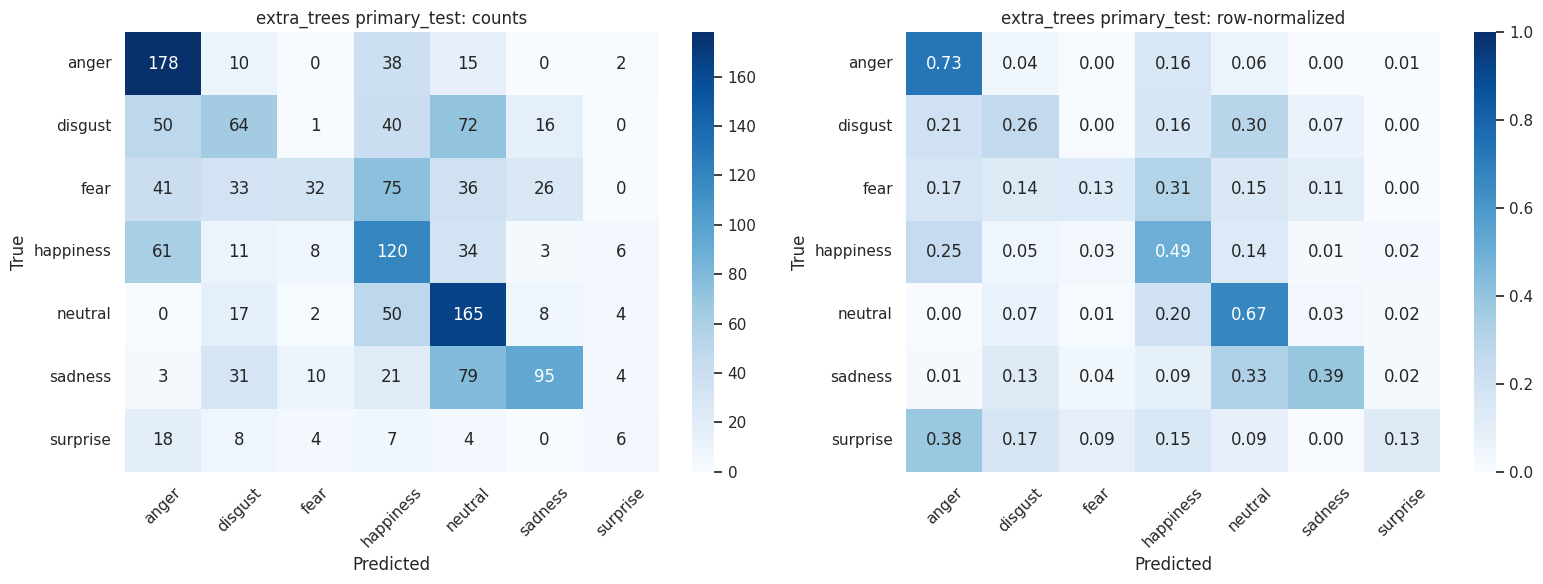

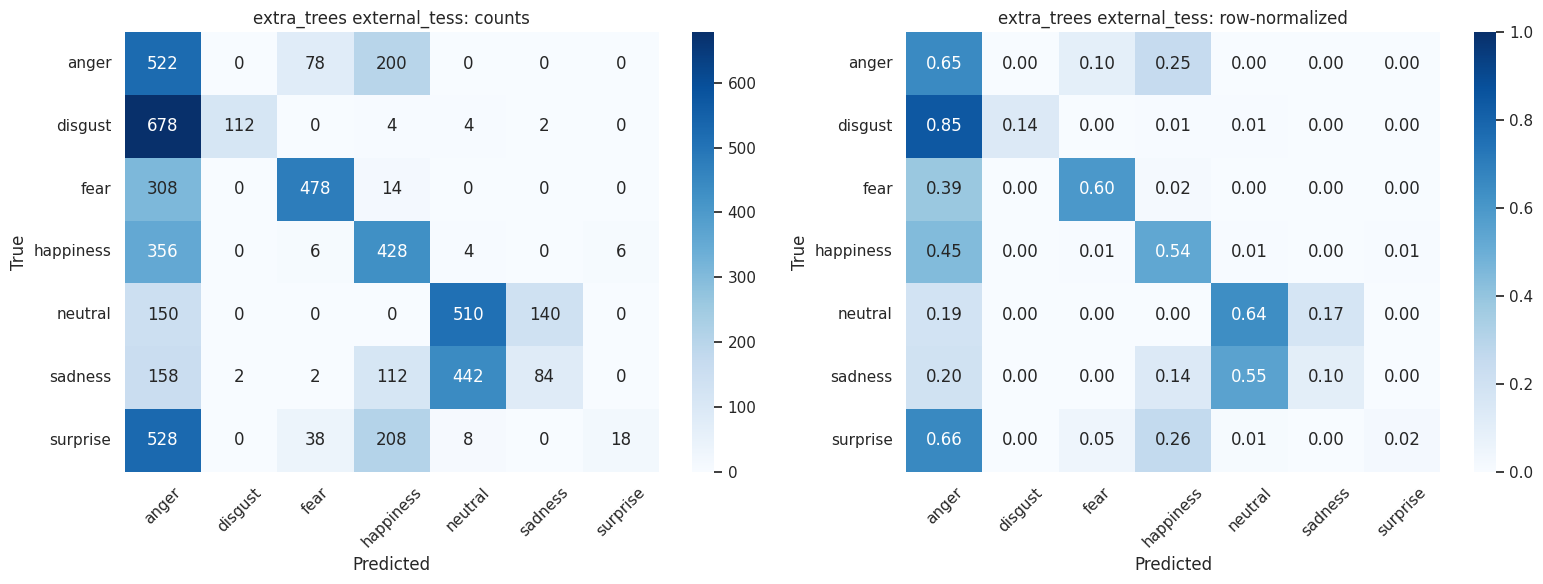

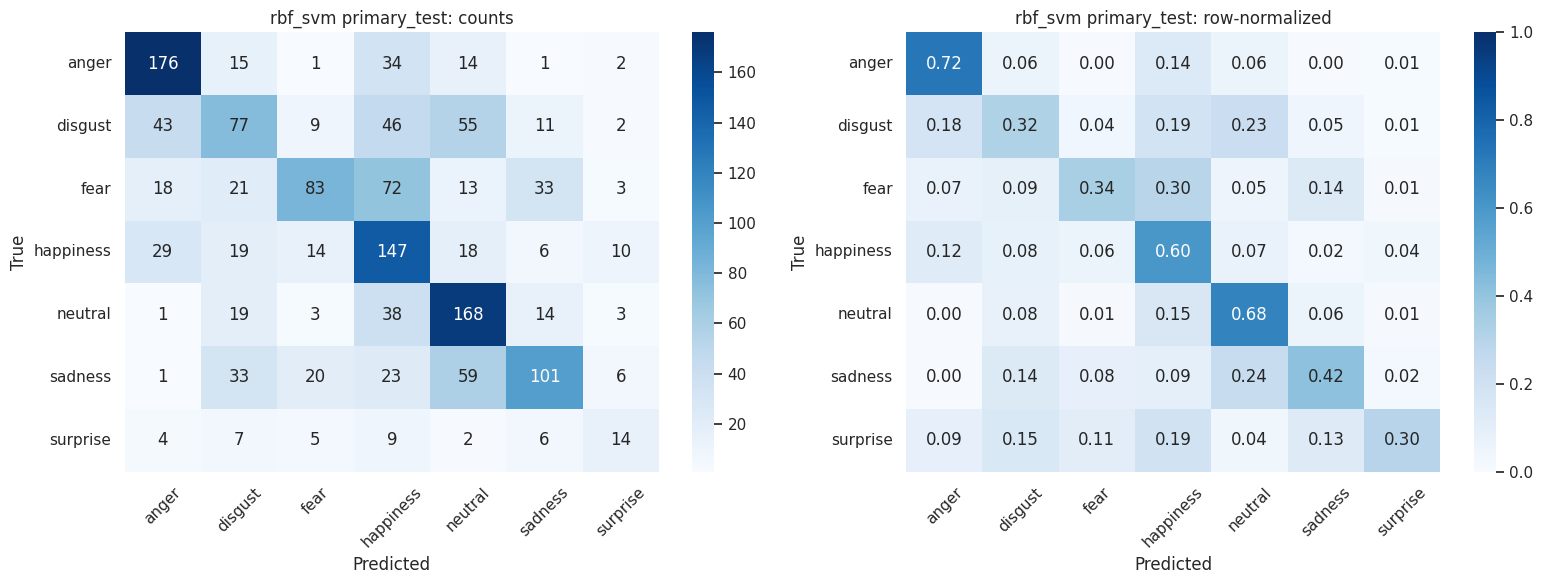

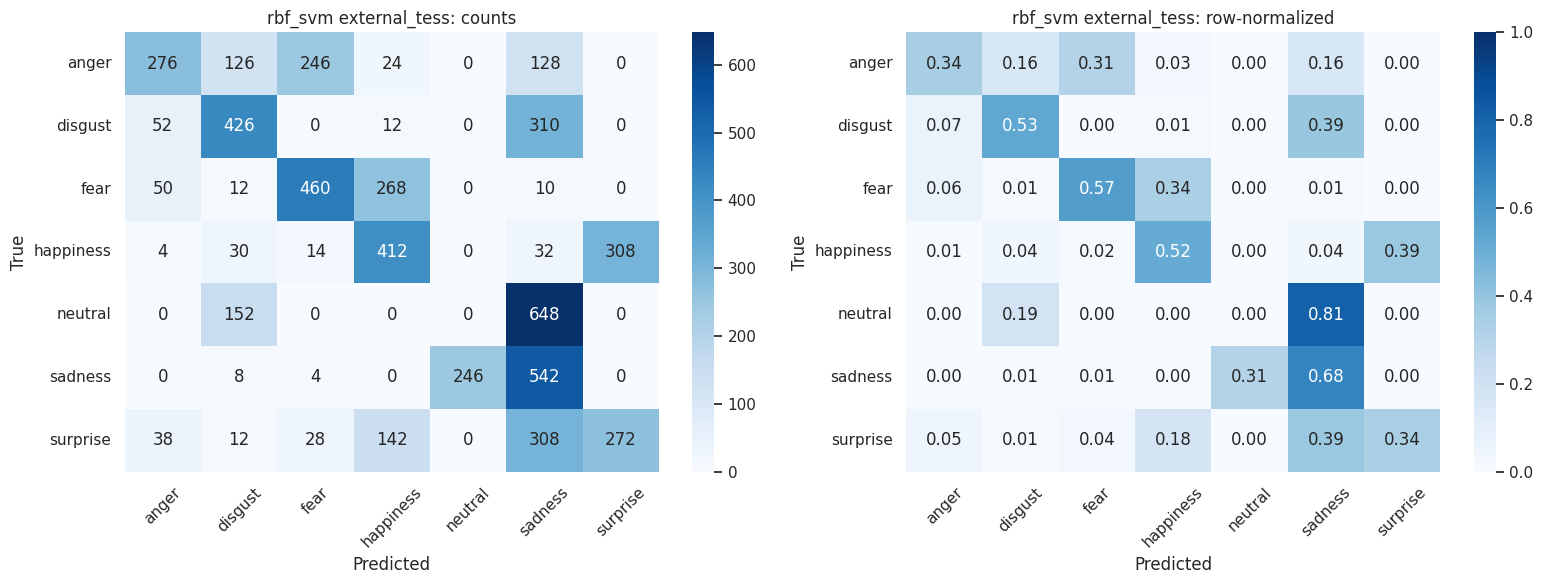

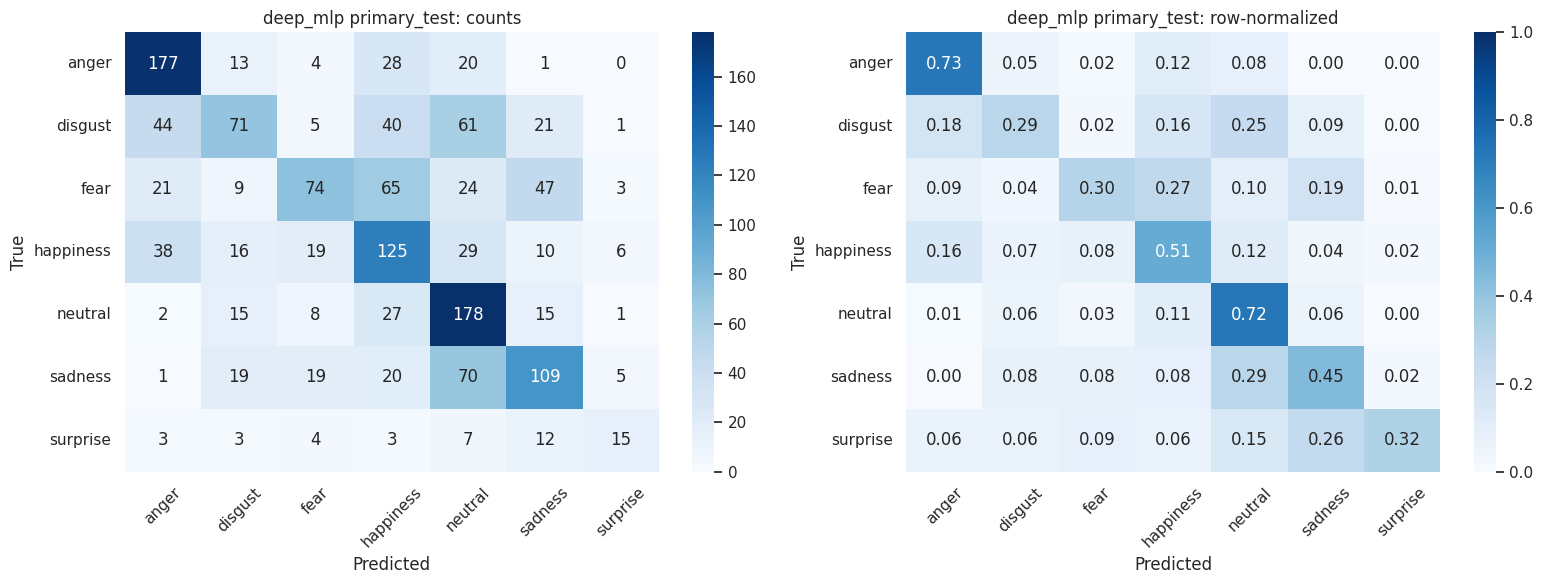

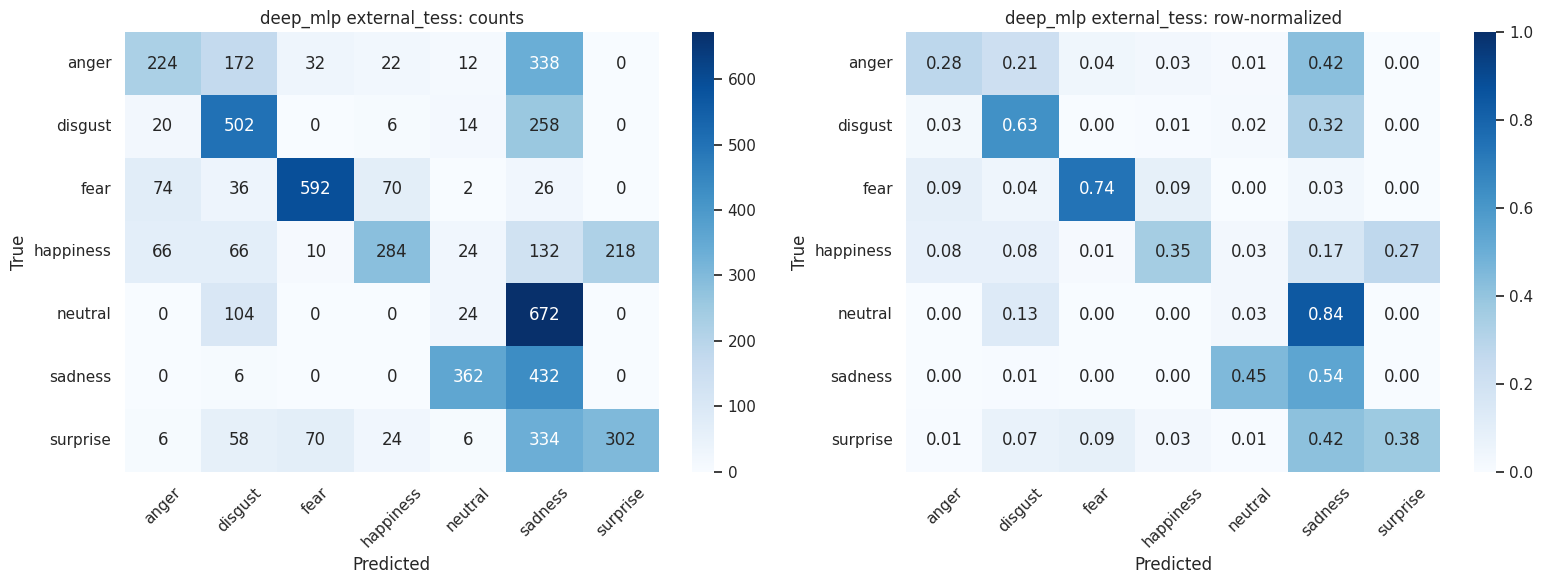

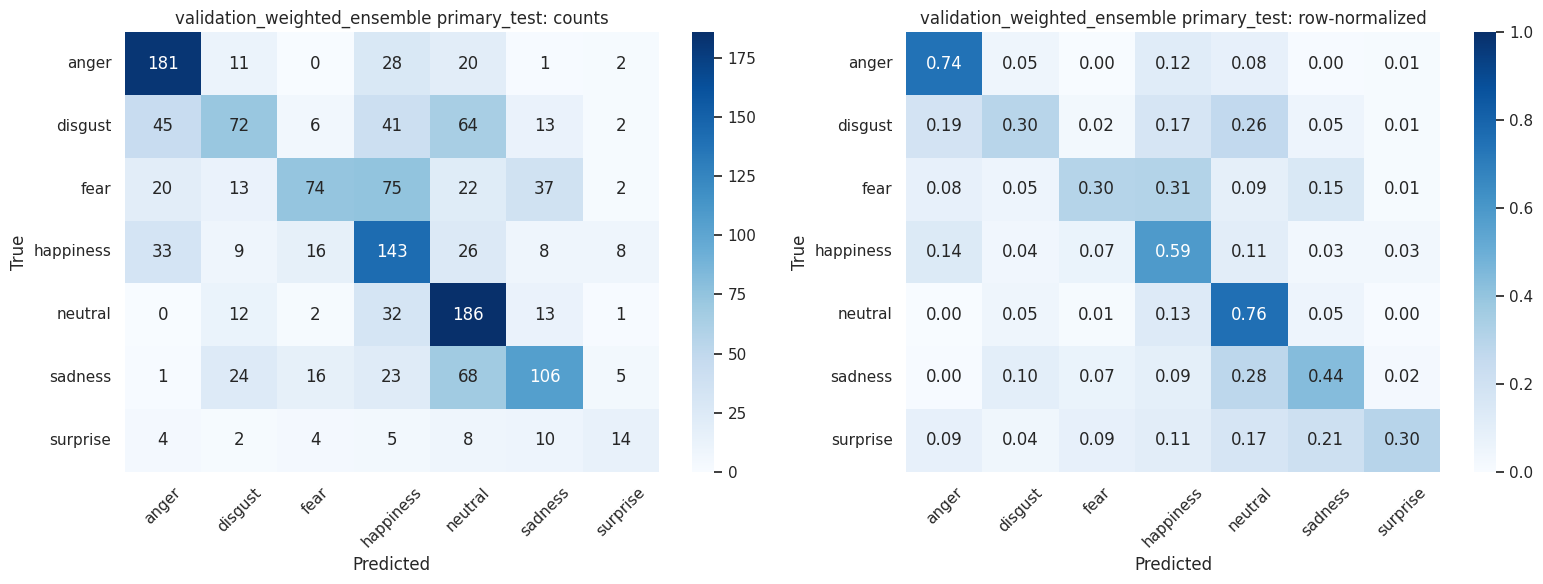

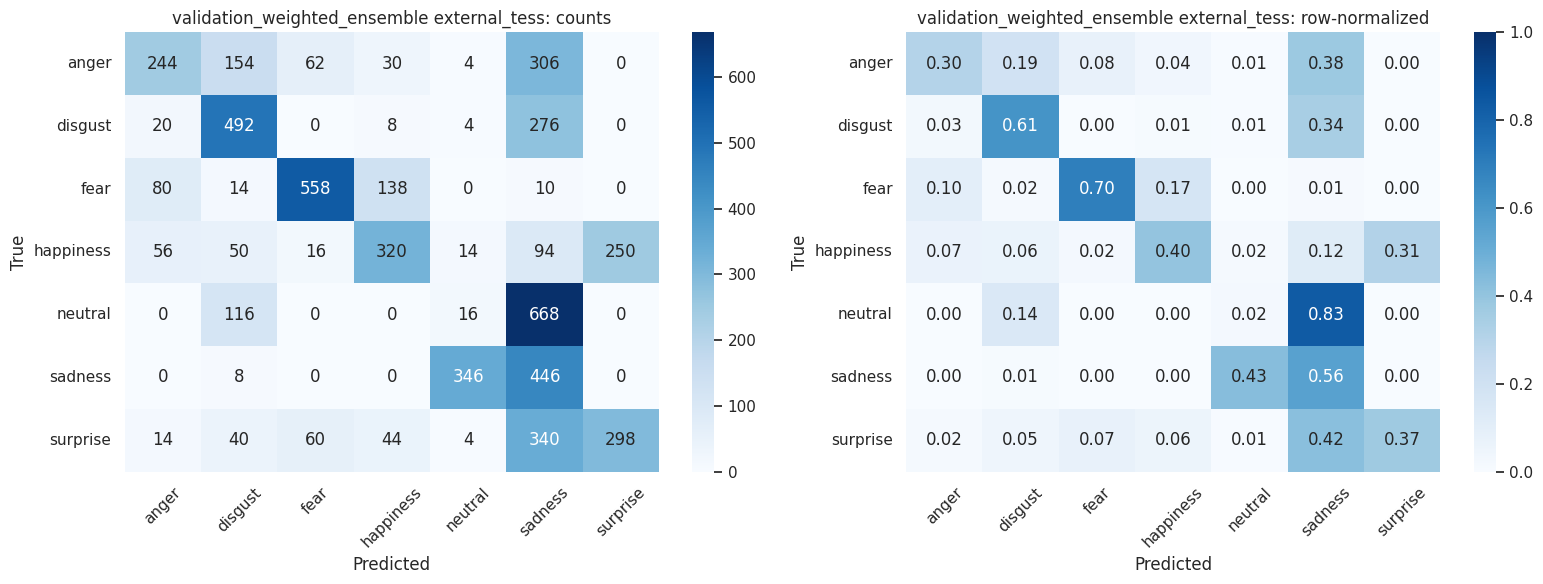

,model,evaluation_set,samples,accuracy,balanced_accuracy,macro_f1,weighted_f1,macro_roc_auc_ovr,nll
5,deep_mlp,external_tess,5600,0.4214,0.4214,0.4279,0.4279,0.7737,3.2958
7,validation_weighted_ensemble,external_tess,5600,0.4239,0.4239,0.4266,0.4266,0.8385,1.5163
3,rbf_svm,external_tess,5600,0.4264,0.4264,0.4101,0.4101,0.7873,1.7327
1,extra_trees,external_tess,5600,0.3843,0.3843,0.3563,0.3563,0.8617,1.5999
6,validation_weighted_ensemble,primary_unseen_speakers,1508,0.5146,0.4892,0.4819,0.4998,0.8539,1.3020
2,rbf_svm,primary_unseen_speakers,1508,0.5080,0.4834,0.4787,0.4993,0.8486,1.3980
4,deep_mlp,primary_unseen_speakers,1508,0.4967,0.4758,0.4718,0.4833,0.7873,1.8649
0,extra_trees,primary_unseen_speakers,1508,0.4377,0.4015,0.3843,0.4119,0.8190,1.4635


,model,dataset,samples,accuracy,macro_f1
6,deep_mlp,CREMA-D,1148,0.5305,0.5196
7,deep_mlp,RAVDESS,240,0.4667,0.4139
8,deep_mlp,SAVEE,120,0.2333,0.0650
0,extra_trees,CREMA-D,1148,0.4669,0.4477
1,extra_trees,RAVDESS,240,0.3458,0.2501
2,extra_trees,SAVEE,120,0.3417,0.2129
3,rbf_svm,CREMA-D,1148,0.5453,0.5375
4,rbf_svm,RAVDESS,240,0.4375,0.3902
5,rbf_svm,SAVEE,120,0.2917,0.1879
9,validation_weighted_ensemble,CREMA-D,1148,0.5557,0.5445


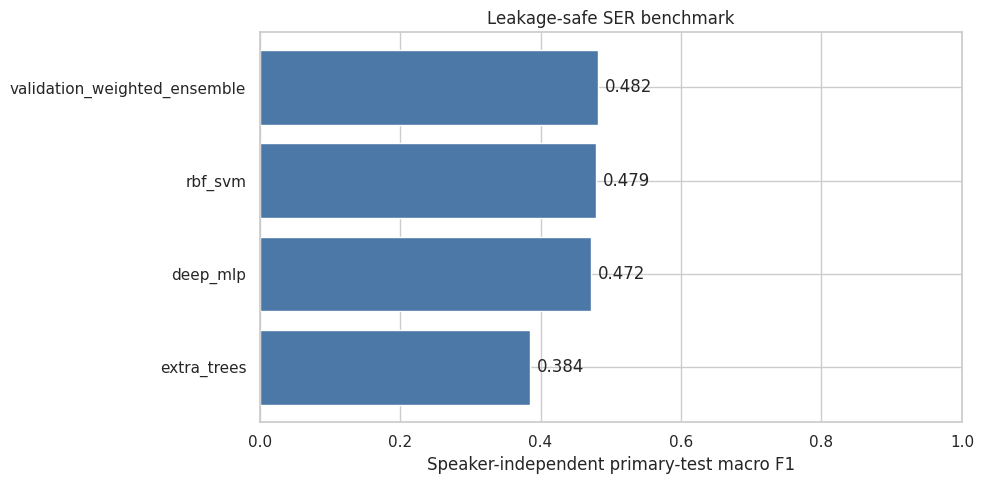

In [13]:
# Evaluate fixed models on the held-out primary test and external TESS
def predict_probabilities(model_name, features):
    registry = model_store[model_name]
    if registry['kind'] == 'sklearn':
        probabilities = registry['model'].predict_proba(features)
    elif registry['kind'] == 'keras':
        probabilities = registry['model'].predict(
            features, batch_size=512, verbose=0
        )
    elif registry['kind'] == 'ensemble':
        probabilities = sum(
            weight * predict_probabilities(member, features)
            for member, weight in zip(
                registry['members'], registry['weights']
            )
        )
    else:
        raise ValueError(f'Unknown model kind: {registry["kind"]}')
    return normalize_probabilities(probabilities)

result_rows = []
test_probability_store = {}
external_probability_store = {}
for name in model_store:
    test_probabilities = predict_probabilities(name, X_test_scaled)
    external_probabilities = predict_probabilities(name, X_external_scaled)
    test_probability_store[name] = test_probabilities
    external_probability_store[name] = external_probabilities
    result_rows.append(metric_row(
        name, y_test, test_probabilities, 'primary_unseen_speakers'
    ))
    result_rows.append(metric_row(
        name, y_external, external_probabilities, 'external_tess'
    ))
    save_diagnostics(name, y_test, test_probabilities, 'primary_test')
    save_diagnostics(name, y_external, external_probabilities, 'external_tess')

results_df = pd.DataFrame(result_rows).sort_values(
    ['evaluation_set', 'macro_f1'], ascending=[True, False]
)
display(results_df.round(4))
results_df.to_csv(ARTIFACT_ROOT / 'final_results.csv', index=False)

corpus_rows = []
test_corpora = feature_data['test']['dataset']
for name, probabilities in test_probability_store.items():
    predictions = probabilities.argmax(axis=1)
    for corpus in sorted(np.unique(test_corpora)):
        mask = test_corpora == corpus
        corpus_rows.append({
            'model': name, 'dataset': corpus, 'samples': int(mask.sum()),
            'accuracy': accuracy_score(y_test[mask], predictions[mask]),
            'macro_f1': f1_score(
                y_test[mask], predictions[mask],
                average='macro', zero_division=0,
            ),
        })
corpus_results_df = pd.DataFrame(corpus_rows)
display(corpus_results_df.sort_values(['model', 'dataset']).round(4))
corpus_results_df.to_csv(
    ARTIFACT_ROOT / 'primary_test_results_by_corpus.csv', index=False
)

primary_plot = results_df[
    results_df.evaluation_set.eq('primary_unseen_speakers')
].sort_values('macro_f1')
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(primary_plot.model, primary_plot.macro_f1, color='#4c78a8')
ax.set_xlim(0, 1)
ax.set_xlabel('Speaker-independent primary-test macro F1')
ax.set_title('Leakage-safe SER benchmark')
for position, value in enumerate(primary_plot.macro_f1):
    ax.text(value + 0.01, position, f'{value:.3f}', va='center')
plt.tight_layout()
plt.savefig(
    ARTIFACT_ROOT / 'primary_test_model_comparison.png',
    dpi=150, bbox_inches='tight',
)
plt.show()

## Deployment-safe inference and integrity report

Inference reuses the training-only scaler and fixed feature extractor. The report records speaker partitions and confirms that TESS was not used during model development.

In [14]:
# Export selection metadata and provide single-file inference
deployment_registry = model_store[deployment_model_name]
deployment_payload = {
    'selected_by': 'validation macro F1 only',
    'model': deployment_model_name,
    'model_kind': deployment_registry['kind'],
    'validation_macro_f1': validation_scores[deployment_model_name],
    'ensemble_members': deployment_registry.get('members'),
    'ensemble_weights': deployment_registry.get('weights'),
    'emotion_labels': EMOTIONS,
    'feature_fingerprint': FEATURE_FINGERPRINT,
}
with open(ARTIFACT_ROOT / 'deployment_selection.json', 'w') as handle:
    json.dump(deployment_payload, handle, indent=2)

def predict_audio_file(filepath, model_name=deployment_model_name):
    audio = load_trimmed_audio(str(filepath))
    features = extract_acoustic_features(audio)[None, :]
    scaled_features = scaler.transform(features).astype(np.float32)
    probabilities = predict_probabilities(model_name, scaled_features)[0]
    prediction_id = int(np.argmax(probabilities))
    return {
        'model': model_name,
        'emotion': ID_TO_EMOTION[prediction_id],
        'confidence': float(probabilities[prediction_id]),
        'probabilities': {
            ID_TO_EMOTION[index]: float(probabilities[index])
            for index in range(len(EMOTIONS))
        },
    }

integrity = {
    'seed': SEED,
    'feature_fingerprint': FEATURE_FINGERPRINT,
    'primary_datasets': PRIMARY_DATASETS,
    'external_dataset': EXTERNAL_DATASET,
    'external_dataset_used_for_training': False,
    'train_files_before_augmentation': int(len(train_manifest)),
    'train_rows_after_augmentation': int(len(y_train)),
    'validation_files': int(len(validation_manifest)),
    'test_files': int(len(test_manifest)),
    'external_files': int(len(external_manifest)),
    'train_speakers': sorted(train_speakers),
    'validation_speakers': sorted(validation_speakers),
    'test_speakers': sorted(test_speakers),
    'speaker_overlap': {
        'train_validation': sorted(train_speakers & validation_speakers),
        'train_test': sorted(train_speakers & test_speakers),
        'validation_test': sorted(validation_speakers & test_speakers),
    },
    'augmentation_applied_to': 'training only',
    'scaler_fitted_on': 'training only',
    'deployment_model': deployment_model_name,
}
assert not any(integrity['speaker_overlap'].values())
with open(ARTIFACT_ROOT / 'integrity_report.json', 'w') as handle:
    json.dump(integrity, handle, indent=2)
print(json.dumps(integrity, indent=2))
print('Artifacts:', ARTIFACT_ROOT)
print("Example: predict_audio_file('/kaggle/input/example/audio.wav')")

{
  "seed": 42,
  "feature_fingerprint": "6c9e75fd5aef",
  "primary_datasets": [
    "RAVDESS",
    "CREMA-D",
    "SAVEE"
  ],
  "external_dataset": "TESS",
  "external_dataset_used_for_training": false,
  "train_files_before_augmentation": 6352,
  "train_rows_after_augmentation": 19056,
  "validation_files": 1502,
  "test_files": 1508,
  "external_files": 5600,
  "train_speakers": [
    "CREMA-D_1001",
    "CREMA-D_1002",
    "CREMA-D_1003",
    "CREMA-D_1004",
    "CREMA-D_1006",
    "CREMA-D_1008",
    "CREMA-D_1009",
    "CREMA-D_1011",
    "CREMA-D_1012",
    "CREMA-D_1013",
    "CREMA-D_1014",
    "CREMA-D_1015",
    "CREMA-D_1017",
    "CREMA-D_1018",
    "CREMA-D_1020",
    "CREMA-D_1021",
    "CREMA-D_1024",
    "CREMA-D_1026",
    "CREMA-D_1027",
    "CREMA-D_1029",
    "CREMA-D_1030",
    "CREMA-D_1031",
    "CREMA-D_1032",
    "CREMA-D_1034",
    "CREMA-D_1035",
    "CREMA-D_1036",
    "CREMA-D_1038",
    "CREMA-D_1041",
    "CREMA-D_1043",
    "CREMA-D_1045",
    "CREMA-D

## Reporting guidance

Use wording such as:

> Models were developed on speaker-disjoint partitions of RAVDESS, CREMA-D and SAVEE. Augmented variants were generated only for training recordings. Preprocessing, checkpoint selection, ensemble weighting and deployment selection used training or validation data only. Final accuracy and macro F1 were measured on unseen primary-test speakers. TESS was evaluated separately as an external-corpus test and was never used for training or model selection.

Do not compare these results directly with the original Kaggle notebook's 60.7% because that notebook split augmented feature rows randomly and repeatedly used its test rows as validation data.